In [1]:
%load_ext autoreload
%autoreload 2

In [40]:
import dotenv

dotenv.load_dotenv()

import xarray as xr
import pandas as pd
import hvplot.xarray
import hvplot.pandas
import numpy as np

import compoundx_figs as cf
from PyCO2SYS.api import CO2SYS_wrap as co2sys

In [41]:
fnames_switch = {
    "aux_vars": "s3://ocean-co2/extremes/aux_vars.zarr/",
    "cexTH": "s3://ocean-co2/extremes/ETHZ1v2025_cexTH_shift_poly2_p95.zarr/",
    "ph_total": "s3://ocean-co2/extremes/ETHZ1v2025_ph_total_Bmean_shift_poly2_p95.zarr/",
    "temperature": "s3://ocean-co2/extremes/ETHZ1v2025_temperature_Bmean_shift_poly2_p95.zarr/",
    "masks": "s3://ocean-co2/extremes/masks.zarr/"
}

In [42]:
ethz = xr.open_dataset("../data/raw/OceanSODA_ETHZ-v2025.OCADS.01-1982-2024.nc")
aux = xr.open_zarr(fnames_switch["aux_vars"])
masks = xr.open_zarr(fnames_switch["masks"])

# BATS test detrending

In [61]:
# Latitude:   31.6667     Longitude:   -64.1667
bats_loc = {"lat": 31.6667, "lon": -64.1667}
vars = ["talk", "dic", "ph_total", "temperature", "salinity"]

bats = ethz.sel(**bats_loc, method="nearest")[vars]
bats['h'] = 10**(-bats.ph_total) * 1e9
bats["dic_trend"] = cf.extreme_detection.trend_poly(bats.dic, order=2)
bats["alk_trend"] = cf.extreme_detection.trend_poly(bats.talk, order=2)
bats["h_trend"] = cf.extreme_detection.trend_poly(bats.h, order=2)
bats["temp_trend"] = cf.extreme_detection.trend_poly(bats.temperature, order=2)
bats["salt_trend"] = cf.extreme_detection.trend_poly(bats.salinity, order=2)

bats["dic_detrend"] = bats.dic - bats.dic_trend + bats.dic.mean()
bats["alk_detrend"] = bats.talk - bats.alk_trend + bats.talk.mean()
bats["h_detrend"] = bats.h - bats.h_trend + bats.h.mean()
bats["temp_detrend"] = bats.temperature - bats.temp_trend + bats.temperature.mean()
bats["salt_detrend"] = bats.salinity - bats.salt_trend + bats.salinity.mean()

bats = bats.sel(time=slice("2000", "2019"))
bats = bats.to_pandas()

In [110]:
bats_computed = co2sys(
    dic=bats.dic_detrend,
    alk=bats.alk_detrend,
    sal=bats.salinity,
    temp_in=bats.temp_detrend,
    si=50,
    po4=0.2,
)
bats_computed.index = bats.index
bats_computed["h"] = 10**(-bats_computed.pHinTOTAL) * 1e9

Convert data to pandas.DataFrame
Removing nans for efficiency
Computing CO2 parameters
Insert nans back into DataFrame


In [111]:
arr = np.array([
    bats.h_detrend.values,
    10**(-bats_computed.pHinTOTAL.values) * 1e9,
    bats.temperature.values,
    bats.temp_detrend.values,
    bats.dic.values,
    bats.dic_detrend.values,
    bats.talk.values,
    bats.alk_detrend.values,]).T

columns = [
    "$D$([H$^+$])",
    "[H$^+$] ← CO2SYS($D$(DIC), $D$(ALK), $D$(T))",
    "T",
    "$D$(T)",
    "DIC",
    "$D$(DIC)",
    "ALK",
    "$D$(ALK)",
]
data = pd.DataFrame(arr, index=bats.index, columns=columns)
data.to_csv("../data/bats_detrended.csv")

In [112]:
from dask.array.wrap import w
blue = "#439fd1"
black = "#000000"
labels = {"xlabel": ""}
img = (
    (
        bats.h_detrend.rename("Φ[H]").hvplot.line()
        * bats_computed.h.rename("pH ← CO2SYS(ΦDIC, ΦALK, ΦTEMP)").hvplot.line(
            color="orange",
            title="pH: direct detrended vs. computed from detrended DIC, ALK, TEMP",
        )
    )
    + (
        bats.temperature.rename("TEMP").hvplot.line(color=black)
        * bats.temp_detrend.rename("ΦTEMP").hvplot.line(
            color=blue, title="Temperature: raw vs. detrended"
        )
    )
    + (
        bats.dic.rename("DIC").hvplot.line(color=black)
        * bats.dic_detrend.rename("ΦDIC").hvplot.line(color=blue, title="DIC: raw vs. detrended")
    )
    + (
        bats.talk.rename("ALK").hvplot.line(color=black, xlabel="")
        * bats.alk_detrend.rename("ΦALK").hvplot.line(
            color=blue, title="ALK: raw vs. detrended", xlabel=""
        )
    )
).cols(2)
# img.opts(title="BATS time series: raw vs. detrended")

## BATS detrended: 2×2 variable-pair figure

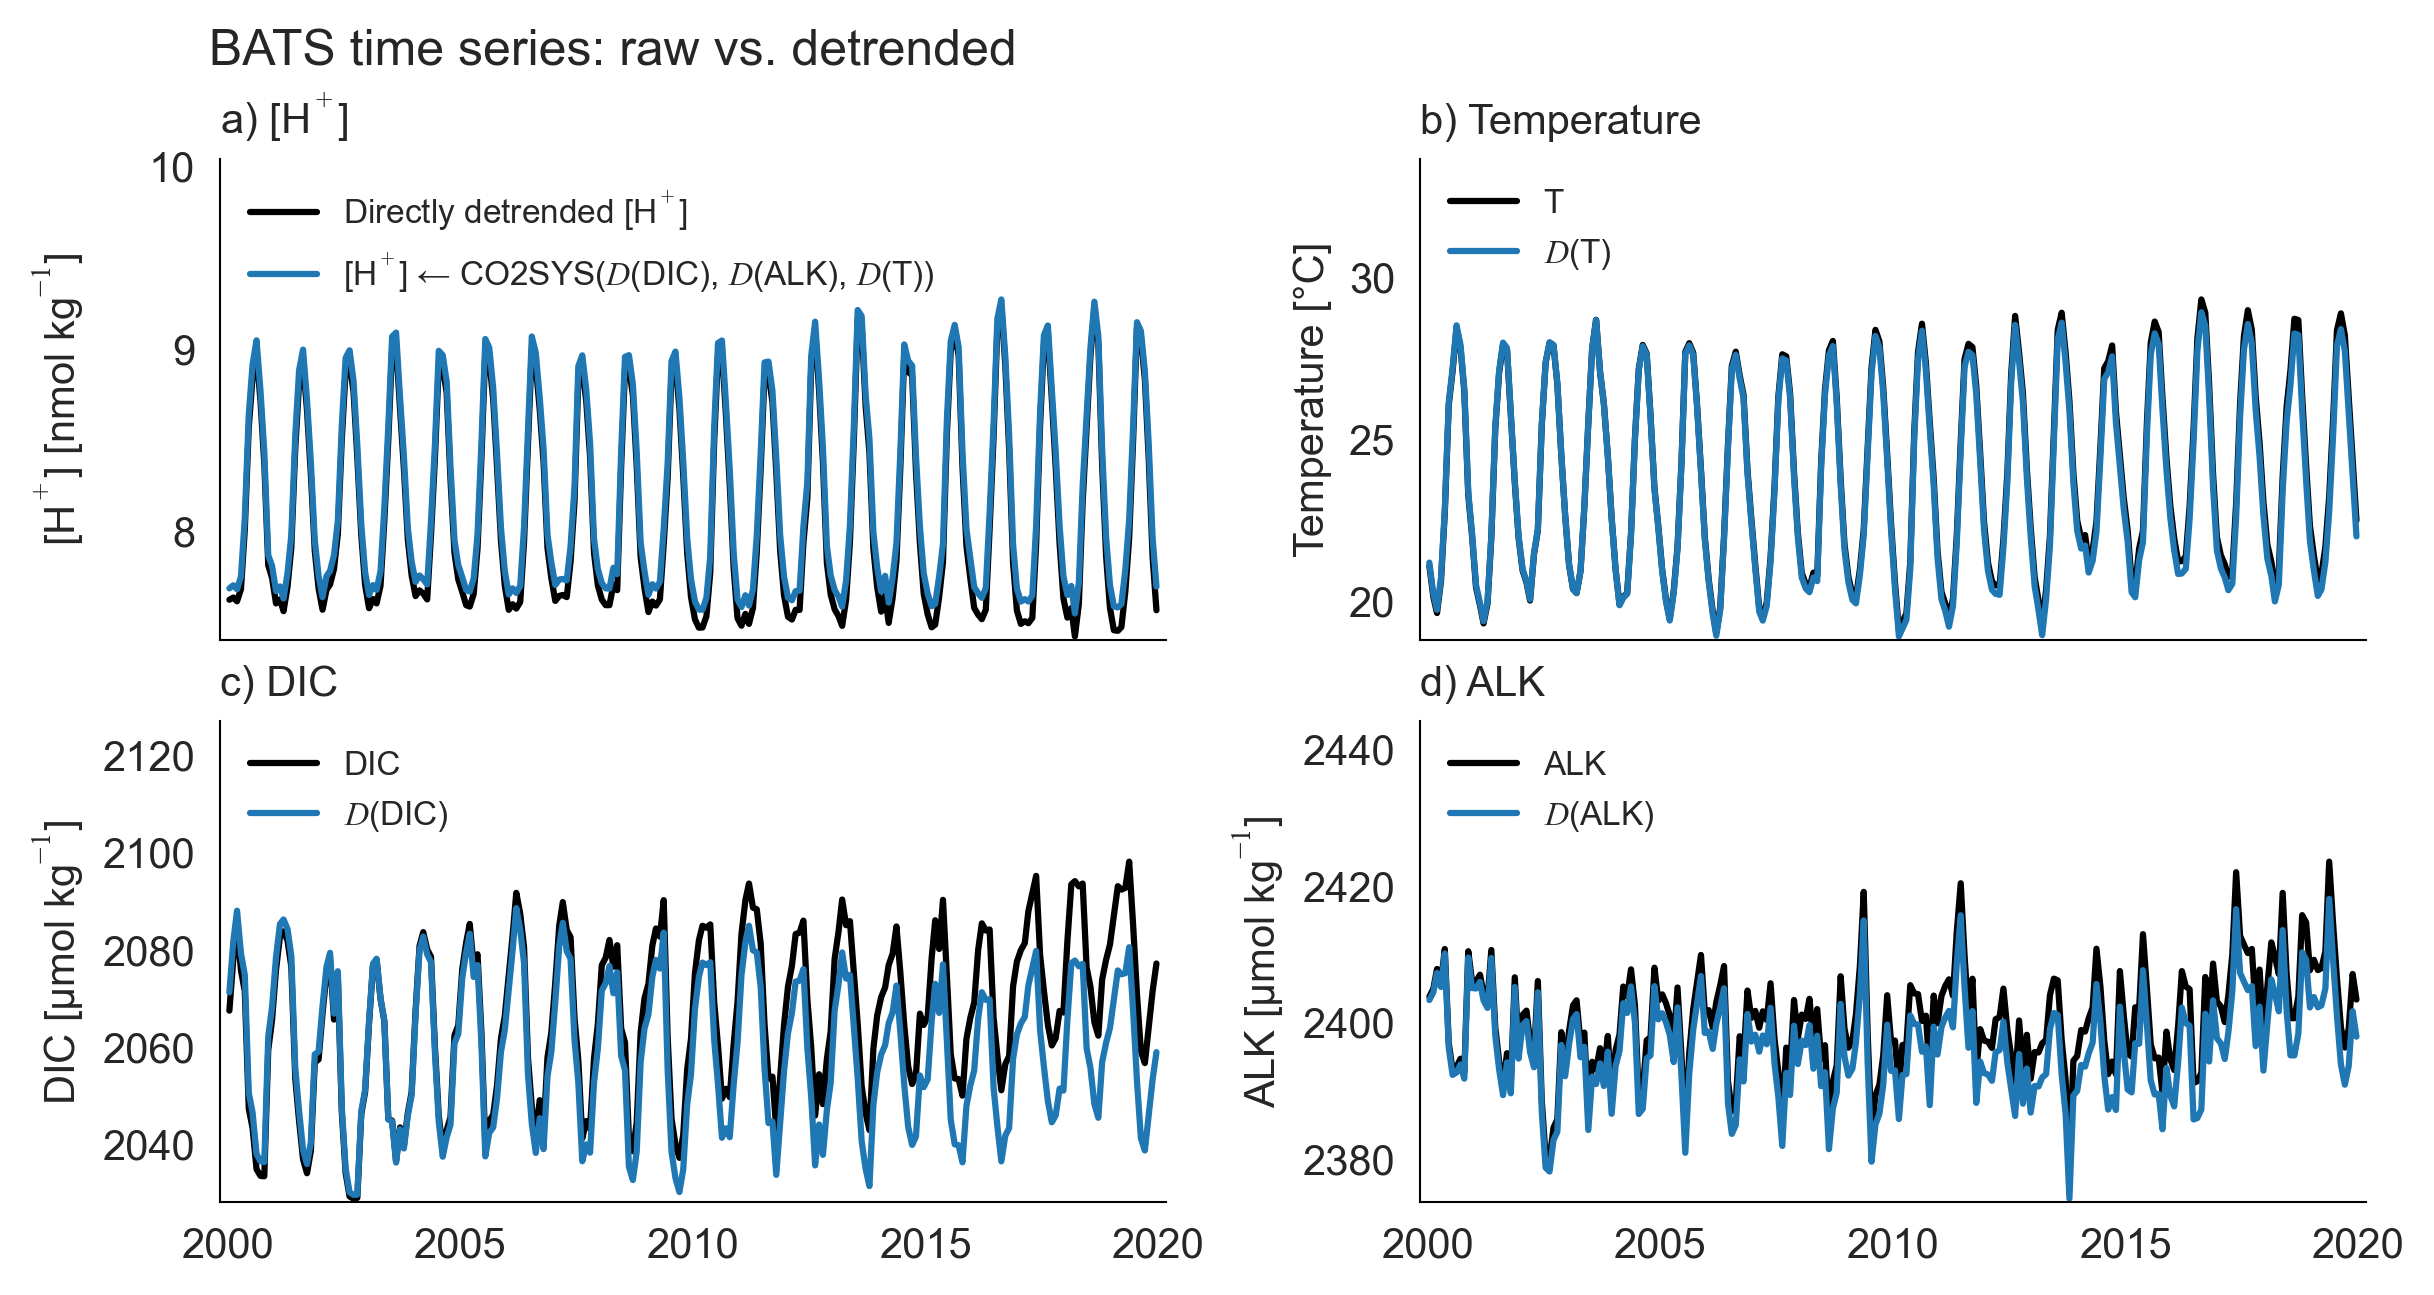

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("./plotting.mplstyle")

df = pd.read_csv("../data/bats_detrended.csv", index_col="time", parse_dates=True)

panels = [
    dict(
        raw="$D$([H$^+$])",
        det="[H$^+$] ← CO2SYS($D$(DIC), $D$(ALK), $D$(T))",
        raw_label="Directly detrended [H$^+$]",
        det_label="[H$^+$] ← CO2SYS($D$(DIC), $D$(ALK), $D$(T))",
        title="a) [H$^+$]",
        ylabel="[H$^+$] [nmol kg$^{-1}$]",
    ),
    dict(
        raw="T",
        det="$D$(T)",
        raw_label="T",
        det_label="$D$(T)",
        title="b) Temperature",
        ylabel="Temperature [°C]",
    ),
    dict(
        raw="DIC",
        det="$D$(DIC)",
        raw_label="DIC",
        det_label="$D$(DIC)",
        title="c) DIC",
        ylabel="DIC [μmol kg$^{-1}$]",
    ),
    dict(
        raw="ALK",
        det="$D$(ALK)",
        raw_label="ALK",
        det_label="$D$(ALK)",
        title="d) ALK",
        ylabel="ALK [μmol kg$^{-1}$]",
    ),
]

fig, axs = plt.subplots(2, 2, figsize=(8, 4), sharex=True, constrained_layout=True)

for ax, p in zip(axs.flat, panels):
    ax.plot(df.index, df[p["raw"]], color="k", lw=1.5, label=p["raw_label"])
    ax.plot(df.index, df[p["det"]], color="#1f77b4", lw=1.5, label=p["det_label"])
    ax.set_title(p["title"], loc="left", size=10)
    ax.set_ylabel(p["ylabel"])
    ax.legend(loc="upper left", fontsize=8)
    y0, y1 = ax.get_ylim()
    y1 = y1 + (y1 - y0) * 0.4
    ax.set_ylim(y0, y1)

for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.align_ylabels(axs[:, 0])
fig.suptitle("BATS time series: raw vs. detrended", size=12, y=1.04, x=axs[0, 0].get_position().x0 + 0.03, ha="left")
fig.savefig("../figures/bats_detrended.pdf", bbox_inches="tight")
plt.show()